# Data analysis
This code is used in order to analize the data generated by the MATLAB code. 
The analysis is ran so that it is possible to understand more deeply the behaviour of the different Neural Networks architectures and some of the choises made 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import h5py

# Specifica il percorso del file .mat v7.3
file_path_LF = './Diffusion/DATA/reaction_diffusion_LF.mat'

# Apre il file con h5py
with h5py.File(file_path_LF, 'r') as file:
    # Ora puoi accedere ai dati all'interno del file
    # Ad esempio, se ci sono gruppi o dataset nel file:
    reaction_LF = file['betas']
    reaction_LF= reaction_LF[()]
    
    U_LF = file['U']
    U_LF=U_LF[()]
    
    V_LF=file['V']
    V_LF=V_LF[()]
    
    x_LF = file['x']
    x_LF=x_LF[()]
    
    y_LF = file['y']
    y_LF=y_LF[()]

# Specifica il percorso del file .mat v7.3
file_path_HF = './Diffusion/DATA/reaction_diffusion_HF.mat'

# Apre il file con h5py
with h5py.File(file_path_HF, 'r') as file:
    # Ora puoi accedere ai dati all'interno del file
    # Ad esempio, se ci sono gruppi o dataset nel file:
    reaction_HF = file['betas']
    reaction_HF= reaction_HF[()]
    
    U_HF = file['U']
    U_HF=U_HF[()]
    
    V_HF=file['V']
    V_HF=V_HF[()]
    
    x_HF = file['x']
    x_HF=x_HF[()]
    
    y_HF = file['y']
    y_HF=y_HF[()]

print(np.shape(U_LF[0,:,:,-1]))

(1601, 32)


In [4]:

def trova_elementi_comuni(array1, array2):
    array1 = np.array(array1)
    array2 = np.array(array2)
    
    elementi_comuni = np.intersect1d(array1, array2)
    
    return elementi_comuni



elementi_comuni = trova_elementi_comuni(x_LF, x_HF)

if elementi_comuni.size > 0:
    print("Elementi comuni tra gli array:", elementi_comuni)
else:
    print("Non ci sono elementi comuni tra gli array.")


Elementi comuni tra gli array: [-10.  10.]


In [9]:
print(x_HF[83])
print(x_LF[26])
print(U_HF[1,10,83,83])
print(U_LF[1,10,26,26])

[6.76767677]
[6.77419355]
-0.9080393278721504
-0.8939785628974152


In [2]:
print(x_LF==x_HF)

False


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_20044\639876525.py:1: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  print(x_LF==x_HF)


In [41]:
int(np.shape(U_LF)[2]/2)

16

In [54]:

print(np.abs(U_LF[0,0,int(np.shape(U_LF)[2]/2),int(np.shape(U_LF)[3]/2)]))

center_HF=int(np.shape(U_HF)[2]/2)
square=U_HF[0,0,center_HF-1:center_HF+2,center_HF-1:center_HF+2]
print(np.mean(square))
print(square)
print(np.abs(U_HF[0,0,int(np.shape(U_HF)[2]/2),int(np.shape(U_HF)[3]/2)]))
print(np.abs(U_HF[0,0,int(np.shape(U_HF)[2]/2)+1,int(np.shape(U_HF)[3]/2)+1]))
print(np.abs(U_HF[0,0,int(np.shape(U_HF)[2]/2)-1,int(np.shape(U_HF)[3]/2)-1]))



#print(np.mean(np.abs(U_LF[0,0,:,:])))
#print(np.mean(np.abs(U_HF[0,0,[int(np.shape(U_HF)[2]/2)-1:int(np.shape(U_HF)[2]/2)+1],[int(np.shape(U_HF)[2]/2)-1:int(np.shape(U_HF)[2]/2)+1]])))


0.4040520199461935
0.12437191109567752
[[-0.1135899  -0.08502344 -0.00071949]
 [ 0.08502344  0.1135899   0.18481442]
 [ 0.24761837  0.30898335  0.37865056]]
0.11358990383693604
0.3786505564191223
0.11358990383693601


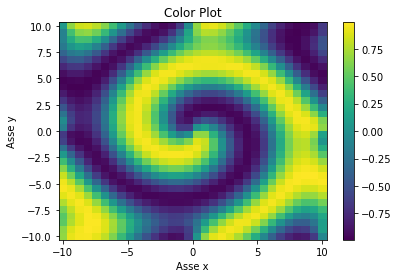

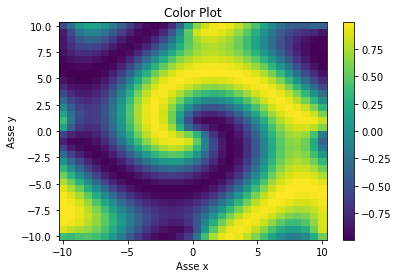

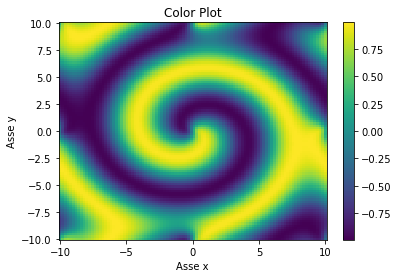

In [29]:
plt.pcolormesh(x_LF[:,0], y_LF[:,0], U_LF[0,801,:,:], shading='auto')  # x, y sono gli assi e Z è la matrice dei dati
plt.colorbar()  # Aggiunge una barra dei colori per indicare i valori corrispondenti ai colori
plt.xlabel('Asse x')
plt.ylabel('Asse y')
plt.title('Color Plot')
plt.show()

plt.pcolormesh(x_LF[:,0], y_LF[:,0], U_LF[0,-1,:,:], shading='auto')  # x, y sono gli assi e Z è la matrice dei dati
plt.colorbar()  # Aggiunge una barra dei colori per indicare i valori corrispondenti ai colori
plt.xlabel('Asse x')
plt.ylabel('Asse y')
plt.title('Color Plot')
plt.show()

plt.pcolormesh(x_HF[:,0], y_HF[:,0], U_HF[0,-1,:,:], shading='auto')  # x, y sono gli assi e Z è la matrice dei dati
plt.colorbar()  # Aggiunge una barra dei colori per indicare i valori corrispondenti ai colori
plt.xlabel('Asse x')
plt.ylabel('Asse y')
plt.title('Color Plot')
plt.show()


# Young modulus

In [3]:
Nlf_models = np.loadtxt("./DATA_shear_cube/Young/Data_Train_bases_young/N_bases.txt").astype(int)   #list of number of base
mu_train_HF = np.loadtxt("./DATA_shear_cube/Young/Data_Train_bases_young/mu_train_HF_young_15.txt")[:,0]
U_hf_train = np.loadtxt("./DATA_shear_cube/Young/Data_Train_bases_young/Uhf_train_young_15.txt")
mu_train_LF = np.loadtxt("./DATA_shear_cube/Young/Data_Train_bases_young/mu_train_LF_young.txt")[:,0]
U_lf_train = np.loadtxt("./DATA_shear_cube/Young/Data_Train_bases_young/Ulf_train_young.txt")
n_bases = U_lf_train.shape[1]                                
m = list(Nlf_models).index(n_bases)
U_lf_train = U_lf_train[:,m]

In [3]:
mu_train_HF = np.loadtxt("./Young_case/DATA_shear_cube/Data_Train_bases_young_new/mu_train_HF_young.txt")[:,0]
U_hf_train = np.loadtxt("./Young_case/DATA_shear_cube/Data_Train_bases_young_new/Uhf_train_young.txt")
mu_train_LF = np.loadtxt("./Young_case/DATA_shear_cube/Data_Train_bases_young_new/mu_train_LF_young.txt")[:,0]
U_lf_train = np.loadtxt("./Young_case/DATA_shear_cube/Data_Train_bases_young_new/Ulf_train_young.txt")
n_bases = U_lf_train.shape[1]                                
#m = list(Nlf_models).index(n_bases)
U_lf_train = U_lf_train[:,-1]

#\Young_case\DATA_shear_cube\Data_Train_bases_young_new

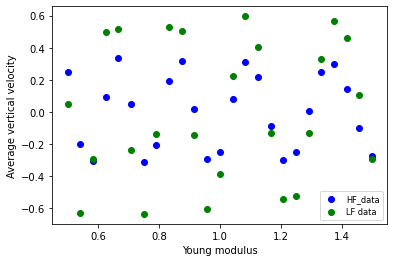

In [76]:

plt.scatter(reaction_HF, U_HF[:,-1,int(np.shape(U_HF)[2]/2),int(np.shape(U_HF)[3]/2)], label='HF_data', color='blue', marker='o')
plt.scatter(reaction_LF, U_LF[:,799,int(np.shape(U_LF)[2]/2),int(np.shape(U_LF)[3]/2)], label='LF data', color='green', marker='o')
plt.xlabel('Young modulus')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()


In [75]:
U=np.mean(np.abs(U_HF[:,-1,:,:]),axis=(1,2))
print(U)

U=np.mean(np.abs(U_LF[:,-1,:,:]),axis=(1,2))
print(U)

[0.62002179 0.61997348 0.61977036 0.61956661 0.61934214 0.6189336
 0.61857202 0.61791344 0.6170764  0.61625591 0.61525046 0.61390519
 0.61242935 0.61061814 0.60893621 0.60708691 0.60491636 0.60260483
 0.59974394 0.59585631 0.59033189 0.58432365 0.58093067 0.57551719
 0.56913428]
[0.6246862  0.62442229 0.62318384 0.61953827 0.61782679 0.61439523
 0.60947189 0.61047243 0.61149159 0.61064252 0.6068892  0.60078356
 0.60107996 0.59639166 0.5919747  0.59318886 0.58599162 0.58268302
 0.57915083 0.57447077 0.57238663 0.56771704 0.56416313 0.56138755
 0.55811793]


# Poisson ratio 

In [6]:
Nlf_models = np.loadtxt("./DATA_shear_cube/Poisson/Data_Train_bases_poisson/N_bases.txt").astype(int)   #list of number of base
mu_train_HF = np.loadtxt("./DATA_shear_cube/Poisson/Data_Train_bases_poisson/mu_train_HF_poisson_15.txt")[:,1]
U_hf_train = np.loadtxt("./DATA_shear_cube/Poisson/Data_Train_bases_poisson/Uhf_train_poisson_15.txt")
mu_train_LF = np.loadtxt("./DATA_shear_cube/Poisson/Data_Train_bases_poisson/mu_train_LF_poisson.txt")[:,1]
U_lf_train = np.loadtxt("./DATA_shear_cube/Poisson/Data_Train_bases_poisson/Ulf_train_poisson.txt")
n_bases = U_lf_train.shape[1]                                
m = list(Nlf_models).index(n_bases)
U_lf_train = U_lf_train[:,m]

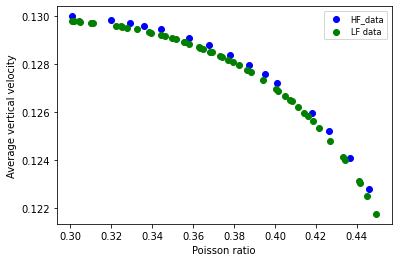

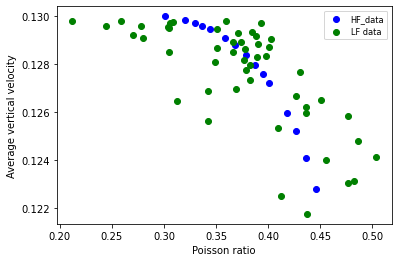

In [7]:
plt.scatter(mu_train_HF, U_hf_train, label='HF_data', color='blue', marker='o')
plt.scatter(mu_train_LF, U_lf_train, label='LF data', color='green', marker='o')
plt.xlabel('Poisson ratio')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()

# ADD NOISE
noise_stddev = 0.05
noise = np.random.normal(0, noise_stddev, len(mu_train_LF))

mu_train_LF=mu_train_LF+noise

plt.scatter(mu_train_HF, U_hf_train, label='HF_data', color='blue', marker='o')
plt.scatter(mu_train_LF, U_lf_train, label='LF data', color='green', marker='o')
plt.xlabel('Poisson ratio')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()

Transformations to reduce linear relationship are not necessary here

# Multiparameter

In [12]:
Nlf_models = np.loadtxt("./Multiparameter/DATA_shear_cube/3p/Data_Train_bases/N_bases.txt").astype(int)   #list of number of base
mu_train_HF = np.loadtxt("./Multiparameter/DATA_shear_cube/3p/Data_Train_bases/mu_train_HF_15.txt")
U_hf_train = np.loadtxt("./Multiparameter/DATA_shear_cube/3p/Data_Train_bases/Uhf_train_15.txt")
mu_train_LF = np.loadtxt("./Multiparameter/DATA_shear_cube/3p/Data_Train_bases/mu_train_LF.txt")
U_lf_train = np.loadtxt("./Multiparameter/DATA_shear_cube/3p/Data_Train_bases/Ulf_train.txt")


In [7]:
mu_train_HF = np.loadtxt("./Multiparameter/DATA_shear_cube/3p/Data_Train_bases_new/mu_train_HF.txt")
U_hf_train = np.loadtxt("./Multiparameter/DATA_shear_cube/3p/Data_Train_bases_new/Uhf_train.txt")
mu_train_LF = np.loadtxt("./Multiparameter/DATA_shear_cube/3p/Data_Train_bases_new/mu_train_LF.txt")
U_lf_train = np.loadtxt("./Multiparameter/DATA_shear_cube/3p/Data_Train_bases_new/Ulf_train.txt")

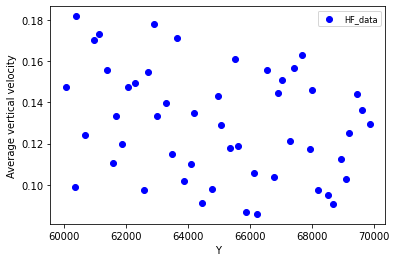

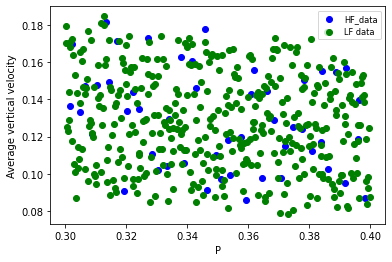

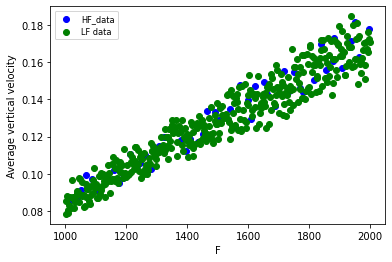

In [8]:
plt.scatter(mu_train_HF[:,0], U_hf_train, label='HF_data', color='blue', marker='o')
plt.scatter(mu_train_LF[:,0], -U_lf_train[:,-1], label='LF data', color='green', marker='o')
plt.xlabel('Y')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()


plt.scatter(mu_train_HF[:,1], U_hf_train, label='HF_data', color='blue', marker='o')
plt.scatter(mu_train_LF[:,1], -U_lf_train[:,-1], label='LF data', color='green', marker='o')
plt.xlabel('P')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()


plt.scatter(mu_train_HF[:,2], U_hf_train, label='HF_data', color='blue', marker='o')
plt.scatter(mu_train_LF[:,2], -U_lf_train[:,-1], label='LF data', color='green', marker='o')
plt.xlabel('F')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()